<a href="https://colab.research.google.com/github/werru-7/lecture1/blob/main/WR_1805_PUM10_systemy_rekomendacyjne_cz2_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dane https://grouplens.org/datasets/movielens/32m/


In [ ]:
ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())
movies = pd.read_csv('/content/movies.csv')


   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858


Wczytanie plikow z selekcja uzytkownikow - tylko dla cwiczenia cz2. w celu redukcji danych

In [ ]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())

movies = pd.read_csv('/content/movies.csv')

# policz liczbę ocen na użytkownika
user_activity = ratings['userId'].value_counts()

# wybierz 100 najbardziej aktywnych użytkowników
top_users = user_activity.head(100).index

# przefiltruj dane
ratings = ratings[ratings['userId'].isin(top_users)]

# opcjonalnie sprawdź wynik
print("Liczba rekordów po filtracji:", len(ratings))
print("Liczba użytkowników:", ratings['userId'].nunique())


   userId  movieId  rating    timestamp
0       1       17     4.0  944249077.0
1       1       25     1.0  944250228.0
2       1       29     2.0  943230976.0
3       1       30     5.0  944249077.0
4       1       32     5.0  943228858.0
Liczba rekordów po filtracji: 316736
Liczba użytkowników: 100


Poznaj dane:


1.   Ile jest ocen filmów?
2.   Ile filmów w bazie?
3.   Ile użytkowników?
4.   Jaka jest średnia liczba ocen na użytkownika i na film?



In [ ]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
#n_movies = movies['movieId'].nunique()
n_users = len(ratings['userId'].unique())

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 316736
Number of unique movieId's: 36001
Number of unique users: 100
Average number of ratings per user: 3167.36
Average number of ratings per movie: 8.8


Jak wygląda rozkład ocen filmów?




/tmp/ipykernel_4883/2038653828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=ratings, palette="viridis")


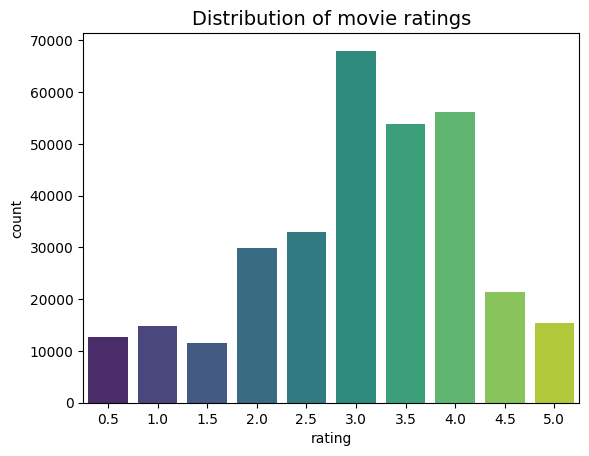

In [ ]:
sns.countplot(x="rating", data=ratings, palette="viridis")
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

In [ ]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings['title'].value_counts()[0:10]

,count
title,
"Terminator, The (1984)",99
"Usual Suspects, The (1995)",99
Pulp Fiction (1994),99
"Matrix, The (1999)",99
Forrest Gump (1994),98
American Beauty (1999),98
Terminator 2: Judgment Day (1991),98
"Sixth Sense, The (1999)",98
Fargo (1996),98


In [ ]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean global rating: 3.07.
Mean rating per user: 3.12.


In [ ]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
print(movies[movies['movieId']==lowest_rated])
highest_rated = mean_ratings['rating'].idxmax()
print(movies[movies['movieId'] == highest_rated])

     movieId                                     title genres
521      526  Savage Nights (Nuits fauves, Les) (1992)  Drama
     movieId                  title genres
434      439  Dangerous Game (1993)  Drama


In [ ]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
434,439,Dangerous Game (1993),Drama


In [ ]:
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()

In [ ]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return bayesian_avg

bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']

movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')
movie_stats.describe()

,movieId,count,mean,bayesian_avg
count,36001.000000,36001.000000,36001.000000,36001.000000
mean,113898.045638,8.797978,2.844995,2.878154
std,81904.087562,15.144388,0.921255,0.254458
min,1.000000,1.000000,0.500000,1.407866
25%,32968.000000,1.000000,2.390625,2.740223
50%,117125.000000,2.000000,3.000000,2.860815
75%,177261.000000,8.000000,3.500000,3.007249
max,292467.000000,99.000000,5.000000,4.246344


In [ ]:
movie_ratings['movieId'].nunique()
M = movie_ratings['userId'].nunique()
user_mapper = dict(zip(np.unique(movie_ratings["userId"]), list(range(M))))

In [ ]:
from scipy.sparse import csr_matrix

def create_sparse(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index, item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_sparse(ratings)

In [ ]:
sparsity = X.count_nonzero()/(X.shape[0]*X.shape[1])

print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 8.87%


Wykorzystaj algorytm najblizszych sąsiadów, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

In [ ]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, k, metric='cosine', show_distance=False):
    """
    Finds k-nearest neighbours for a given movie id.

    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations

    Returns:
        list of k similar movie ID's
    """
    neighbour_ids = []

    # Transpose the user-item matrix X to an item-user matrix X_movies
    # Now, each row in X_movies corresponds to a movie, and columns to users
    X_movies = X.T

    # Get the internal index for the movie_id from movie_mapper
    # This index is a row index in X_movies
    target_movie_idx = movie_mapper[movie_id]

    # Extract the vector for the target movie from X_movies
    target_movie_vec = X_movies[target_movie_idx]

    # Initialize kNN model. k+1 because the movie itself will be the closest neighbor
    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X_movies) # Fit the model on the movie-user matrix

    # Reshape movie_vec if it's a 1D array to a 2D array for kneighbors
    if isinstance(target_movie_vec, (np.ndarray)):
        target_movie_vec = target_movie_vec.reshape(1,-1)

    # Find k+1 nearest neighbors (distances and indices)
    if show_distance:
        distances, indices = kNN.kneighbors(target_movie_vec, return_distance=True)
    else:
        indices = kNN.kneighbors(target_movie_vec, return_distance=False)

    # Iterate through the neighbors, skipping the first one (the movie itself)
    for i in range(1, len(indices[0])):
        # 'idx' is the internal index of the similar movie in the sparse matrix
        idx = indices[0][i]
        # Map this internal index back to the original movieId using movie_inv_mapper
        neighbour_ids.append(movie_inv_mapper[idx])

    return neighbour_ids

In [ ]:
movie_titles = dict(zip(movies['movieId'], movies['title']))
movie_id = 1

similar_ids = find_similar_movies(movie_id, X, k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}")
for i in similar_ids:
    print(movie_titles[i])

Because you watched Toy Story (1995)
Toy Story 2 (1999)
Finding Nemo (2003)
Minority Report (2002)
Star Wars: Episode V - The Empire Strikes Back (1980)
Incredibles, The (2004)
Monsters, Inc. (2001)
Memento (2000)
Up (2009)
Seven (a.k.a. Se7en) (1995)
Shrek (2001)


Wykorzystaj algorytm SVD, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

cz1: klasyczne SVD (biblioteka **NumPy**)

In [22]:
import numpy as np

def svd_reconstruct(R, k=2):
    """
    Aproksymacja macierzy przez klasyczne SVD
    """
    U, sigma, Vt = np.linalg.svd(R, full_matrices=False)

    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    R_approx = np.dot(U_k, np.dot(sigma_k, Vt_k))

    return R_approx

cz2: TruncatedSVD (scikit-learn)


In [23]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

def truncated_svd_reconstruct(R, k=2):
    """
    Aproksymacja macierzy przez TruncatedSVD (sklearn)
    """
    svd = TruncatedSVD(n_components=k, random_state=42)
    R_transformed = svd.fit_transform(R)
    R_approx = svd.inverse_transform(R_transformed)

    return R_approx

wywołaj obie funkcje i stworz rekomentacje dla uzytkownika nr 10

In [37]:
user_id = list(user_mapper.keys())[10]
user_idx = user_mapper[user_id]


R_svd = svd_reconstruct(X.toarray(), k=20)   # UWAGA: musi być gęsta macierz

R_trunc = truncated_svd_reconstruct(X, k=2)

def get_recommendations(R_original, R_pred, user_idx):
    recs = []
    user_ratings = R_original[user_idx]
    user_preds = R_pred[user_idx]

    for i in range(len(user_ratings)):
        if user_ratings[i] == 0:
            movie_id = movie_inv_mapper[i]
            recs.append((movie_id, user_preds[i]))

    return sorted(recs, key=lambda x: x[1], reverse=True)

recs_svd = get_recommendations(X.toarray(), R_svd, user_idx)
recs = get_recommendations(X.toarray(), R_trunc, user_idx)

print(f"ID użytkownika: {user_id}")

print("Top 10 svd:")
for movie_id, rating in recs_svd[:10]:
    print(f"{movie_titles[movie_id]} {rating:.4f}")

print("-------------------------------")

print("Top 10 truncated svd:")
for movie_id, rating in recs[:10]:
    print(f"{movie_titles[movie_id]} {rating:.4f}")

ID użytkownika: 3367
Top 10 svd:
Sherlock Holmes: A Game of Shadows (2011) 4.4125
Equalizer, The (2014) 3.8155
Robin Hood: Men in Tights (1993) 3.7812
Lincoln Lawyer, The (2011) 3.5720
Analyze This (1999) 3.5640
Amazing Spider-Man, The (2012) 3.5190
How to Train Your Dragon 2 (2014) 3.4491
Fracture (2007) 3.4274
Apocalypto (2006) 3.4079
Legends of the Fall (1994) 3.4059
-------------------------------
Top 10 truncated svd:
Gone Girl (2014) 3.7161
Drive (2011) 3.6108
Cabin in the Woods, The (2012) 3.4976
Prisoners (2013) 3.4643
Unforgiven (1992) 3.3855
American Psycho (2000) 3.3554
Sherlock Holmes: A Game of Shadows (2011) 3.2873
Equalizer, The (2014) 3.2261
First Blood (Rambo: First Blood) (1982) 3.2251
Amazing Spider-Man, The (2012) 3.2125


KLUCZOWA różnica (najważniejsze)
SVD:

* działa na pełnej macierzy
* traktuje brak ocen jako 0 → to jest BŁĄD modelowy

TruncatedSVD:

* działa na macierzy sparse
* ale nadal NIE rozróżnia: brak oceny vs słaba ocena



Ocena modeli - policz RSME na macierzach tylko na niezerowych elementach

In [34]:
from sklearn.metrics import mean_squared_error

R_dense = X.toarray()

mask = R_dense > 0

original_ratings = R_dense[mask]
svd_ratings = R_svd[mask]
trunc_ratings = R_trunc[mask]

rmse_svd = np.sqrt(mean_squared_error(original_ratings, svd_ratings))
rmse_trunc = np.sqrt(mean_squared_error(original_ratings, trunc_ratings))

print(f"rmse dla klasycznego svd (k=20): {rmse_svd:.4f}")
print(f"rmse dla TruncatedSVD (k=2): {rmse_trunc:.4f}")

rmse dla klasycznego svd (k=20): 1.5255
rmse dla TruncatedSVD (k=2): 2.1463
